<a href="https://colab.research.google.com/github/Evgenii1994/DLS2/blob/main/week_05_attention/homework/Attention_and_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig
from typing import Union


class TransformerClassificationModel(nn.Module):
    def __init__(
        self,
        base_transformer_model: Union[str, nn.Module],
        num_classes: int = 2,
        dropout: float = 0.1,
        use_complex_head: bool = True,
        pooling: str = "cls"  # 'cls', 'mean', 'pooler'
    ):
        super().__init__()

        if isinstance(base_transformer_model, str):
            self.config = AutoConfig.from_pretrained(base_transformer_model, num_labels=num_classes)
            self.backbone = AutoModel.from_pretrained(base_transformer_model, config=self.config)
        elif isinstance(base_transformer_model, nn.Module):
            self.backbone = base_transformer_model
            self.config = base_transformer_model.config
        else:
            raise ValueError("Should be str or nn.Module")

        self.pooling = pooling.lower()
        hidden_size = self.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        if use_complex_head:
            self.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(hidden_size, 256),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(256, num_classes)
            )
        else:
            self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        kwargs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        }
        if token_type_ids is not None and "token_type_ids" in self.backbone.forward.__code__.co_varnames:
            kwargs["token_type_ids"] = token_type_ids

        outputs = self.backbone(**kwargs)

        if self.pooling == "cls":
            pooled_output = outputs.last_hidden_state[:, 0, :]
        elif self.pooling == "mean":
            pooled_output = (outputs.last_hidden_state * attention_mask.unsqueeze(-1)).sum(dim=1) / attention_mask.sum(dim=1, keepdim=True)
        elif self.pooling == "pooler":
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                pooled_output = outputs.pooler_output
            else:
                raise ValueError("Model does not provide pooler_output. Use 'cls' or 'mean' instead.")
        else:
            raise ValueError(f"Unknown pooling method: {self.pooling}")

        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return {"logits": logits}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [ ]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model, dataloader, device, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

            if criterion:
                loss = criterion(logits, labels)
                total_loss += loss.item()
                count += 1

    avg_loss = total_loss / count if count > 0 else None
    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro"),
        "f1_weighted": f1_score(all_labels, all_preds, average="weighted"),
        "loss": avg_loss
    }


In [ ]:
import copy
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, f1_score


def train_transformer(
    transformer_model,
    train_loader=None,
    val_loader=None,
    num_epochs=20,
    lr=2e-5,
    device=None,
    freeze_backbone=True,
    log_dir="runs/transformer_run",
    checkpoint_dir="checkpoints",
    early_stopping_patience=3,
    reduce_lr_patience=2,
    reduce_lr_factor=0.5,
    class_weights=None
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=log_dir)

    model = copy.deepcopy(transformer_model)
    log_val_every_n_steps = len(train_loader) // 2

    if freeze_backbone:
        model = freeze_backbone_function(model)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.AdamW([
        {"params": model.backbone.parameters(), "lr": 1e-6},
        {"params": model.classifier.parameters(), "lr": 1e-3}
    ])

    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=reduce_lr_factor,
        patience=reduce_lr_patience,
        verbose=True
    )

    best_val_f1 = -1
    best_metrics = {}
    epochs_no_improve = 0

    total_batches = len(train_loader)
    total_steps = total_batches * num_epochs
    global_step = 0
    overall_progress = tqdm(total=total_steps, desc=f"0.000 of {num_epochs} epochs")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for i, batch in enumerate(train_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            global_step += 1
            epoch_loss += loss.item()
            writer.add_scalar("Loss/train_step", loss.item(), global_step)

            if val_loader is not None and (i + 1) % log_val_every_n_steps == 0:
                model.eval()
                val_metrics = evaluate_model(model, val_loader, device, criterion)
                writer.add_scalar("Loss/val_step", val_metrics["loss"], global_step)
                writer.add_scalar("Accuracy/val_step", val_metrics["accuracy"], global_step)
                writer.add_scalar("F1_macro/val_step", val_metrics["f1_macro"], global_step)
                writer.add_scalar("F1_weighted/val_step", val_metrics["f1_weighted"], global_step)
                print(f"[Step {global_step}] Val Acc: {val_metrics['accuracy']:.4f} — "
                      f"F1_macro: {val_metrics['f1_macro']:.4f} — "
                      f"F1_weighted: {val_metrics['f1_weighted']:.4f}")
                model.train()

            fractional_epoch = global_step / total_batches
            if global_step % max(1, total_batches // 50) == 0:
                overall_progress.set_description(f"{fractional_epoch:.3f} of {num_epochs} epochs")

            overall_progress.update(1)

        avg_loss = epoch_loss / total_batches
        writer.add_scalar("Loss/train_epoch", avg_loss, epoch)

        train_metrics = evaluate_model(model, train_loader, device)
        writer.add_scalar("Accuracy/train_epoch", train_metrics["accuracy"], epoch)
        writer.add_scalar("F1_macro/train_epoch", train_metrics["f1_macro"], epoch)
        writer.add_scalar("F1_weighted/train_epoch", train_metrics["f1_weighted"], epoch)

        if val_loader is not None:
            val_metrics = evaluate_model(model, val_loader, device, criterion)
            writer.add_scalar("Loss/val_epoch", val_metrics["loss"], epoch)
            writer.add_scalar("Accuracy/val_epoch", val_metrics["accuracy"], epoch)
            writer.add_scalar("F1_macro/val_epoch", val_metrics["f1_macro"], epoch)
            writer.add_scalar("F1_weighted/val_epoch", val_metrics["f1_weighted"], epoch)

            print(f"[Epoch {epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} — "
                  f"Train Acc: {train_metrics['accuracy']:.4f} — Val Acc: {val_metrics['accuracy']:.4f} — "
                  f"F1_macro: {val_metrics['f1_macro']:.4f} — F1_weighted: {val_metrics['f1_weighted']:.4f}")

            scheduler.step(val_metrics["f1_macro"])

            if val_metrics["f1_macro"] > best_val_f1:
                best_val_f1 = val_metrics["f1_macro"]
                epochs_no_improve = 0
                best_metrics = {
                    "epoch": epoch + 1,
                    "val_accuracy": val_metrics["accuracy"],
                    "f1_macro": val_metrics["f1_macro"],
                    "f1_weighted": val_metrics["f1_weighted"],
                    "loss": val_metrics["loss"]
                }
                torch.save(model.state_dict(), os.path.join(checkpoint_dir, f"best_model.pt"))
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stopping_patience:
                    print("⛔ Early stopping triggered.")
                    break

        else:
            print(f"[Epoch {epoch+1}/{num_epochs}] — Loss: {avg_loss:.4f}")

        torch.save(model.state_dict(), os.path.join(checkpoint_dir, f"model_epoch_{epoch+1}.pt"))

    overall_progress.close()
    writer.close()

    if best_metrics:
        print("\n\n🏆 Best validation results achieved:")
        print(f"  • Epoch: {best_metrics['epoch']}")
        print(f"  • Accuracy: {best_metrics['val_accuracy']:.4f}")
        print(f"  • F1_macro: {best_metrics['f1_macro']:.4f}")
        print(f"  • F1_weighted: {best_metrics['f1_weighted']:.4f}")
        print(f"  • Loss: {best_metrics['loss']:.4f}")

    return model


2025-04-14 19:36:57.888626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744659418.098259      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744659418.161490      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Отрисовка результатов экспериментов:

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from scipy.ndimage import gaussian_filter1d

def find_event_file(log_dir):
    for root, _, files in os.walk(log_dir):
        for file in files:
            if "tfevents" in file:
                return os.path.join(root, file)
    raise FileNotFoundError(f"No TensorBoard event file found in {log_dir}")

def load_scalar(log_file, tag):
    ea = EventAccumulator(log_file)
    ea.Reload()
    if tag not in ea.Tags()["scalars"]:
        return [], []
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values

def plot_training_logs(tb_log_dir, steps_per_epoch, smooth_step_curves=True, smooth_sigma=5):
    log_file = find_event_file(tb_log_dir)

    metric_configs = [
        {
            "title": "Loss",
            "train_tag": "Loss/train_epoch",
            "val_tag": "Loss/val_epoch",
            "train_step_tag": "Loss/train_step",
            "val_step_tag": "Loss/val_step"
        },
        {
            "title": "Accuracy",
            "train_tag": "Accuracy/train_epoch",
            "val_tag": "Accuracy/val_epoch",
            "train_step_tag": None,
            "val_step_tag": "Accuracy/val_step"
        },
        {
            "title": "F1-macro",
            "train_tag": "F1_macro/train_epoch",
            "val_tag": "F1_macro/val_epoch",
            "train_step_tag": None,
            "val_step_tag": "F1_macro/val_step"
        },
        {
            "title": "F1-weighted",
            "train_tag": "F1_weighted/train_epoch",
            "val_tag": "F1_weighted/val_epoch",
            "train_step_tag": None,
            "val_step_tag": "F1_weighted/val_step"
        }
    ]
    fig, axs = plt.subplots(1, len(metric_configs), figsize=(6 * len(metric_configs), 4))

    for ax, config in zip(axs, metric_configs):
        has_data = False

        # Epoch-level plots
        if config["train_tag"]:
            x, y = load_scalar(log_file, config["train_tag"])
            if x and y:
                ax.plot(x, y, label="Train (epoch)", color="tab:blue", linewidth=2)
                has_data = True

        if config["val_tag"]:
            x, y = load_scalar(log_file, config["val_tag"])
            if x and y:
                ax.plot(x, y, label="Val (epoch)", color="tab:orange", linewidth=2)
                has_data = True

        # Step-level plots
        for tag, label, color, style in [
            (config["train_step_tag"], "Train (step)", "tab:blue", "--"),
            (config["val_step_tag"], "Val (step)", "tab:orange", "--")
        ]:
            if tag:
                x, y = load_scalar(log_file, tag)
                if x and y:
                    x = [step / steps_per_epoch for step in x]
                    if smooth_step_curves and len(y) > 10:
                        y = gaussian_filter1d(y, sigma=smooth_sigma)
                    ax.plot(x, y, label=label, color=color, linestyle=style, alpha=0.6)
                    has_data = True

        ax.set_title(config["title"])
        ax.set_xlabel("Epochs")
        ax.grid(True)
        if has_data:
            ax.legend()
        else:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                    ha='center', va='center', fontsize=12, color='gray')

    plt.tight_layout()
    plt.show()


In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os


def print_available_tags(log_dir):
    ea = EventAccumulator(log_dir)
    ea.Reload()
    print("Available scalar tags:")
    for tag in ea.Tags()["scalars"]:
        print(f"  - {tag}")


def find_event_file(log_dir):
    for root, dirs, files in os.walk(log_dir):
        for file in files:
            if "tfevents" in file:
                return os.path.join(root, file)
    raise FileNotFoundError("No TensorBoard event file found in " + log_dir)


def print_scalar_lengths(log_dir, tags):
    print(f"📁 Scanning: {log_dir}")
    ea = EventAccumulator(log_dir)
    ea.Reload()

    for tag in tags:
        if tag in ea.Tags()["scalars"]:
            count = len(ea.Scalars(tag))
            print(f"✅ {tag} → {count} values")
        else:
            print(f"❌ {tag} → not found")

## Подготовка данных:

In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import torch

from torch.utils.data import Dataset
from transformers import PreTrainedTokenizer
import torch
from typing import List, Dict, Optional

class TextClassificationDataset(Dataset):
    def __init__(
        self,
        texts: List[str],
        labels: List[str],
        tokenizer: PreTrainedTokenizer,
        label2id: Optional[Dict[str, int]] = None,
        max_length: int = 128
    ):
        self.tokenizer = tokenizer
        self.max_length = max_length

        if label2id is None:
            unique_labels = sorted(set(labels))
            self.label2id = {label: idx for idx, label in enumerate(unique_labels)}
        else:
            self.label2id = label2id

        self.id2label = {v: k for k, v in self.label2id.items()}

        self.labels = [self.label2id[label] for label in labels]

        self.encodings = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

### Скачиваем данные:

In [ ]:
!wget --no-check-certificate "https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/export?format=csv&gid=661202001" -O data.csv

--2025-04-14 19:37:10--  https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/export?format=csv&gid=661202001
Resolving docs.google.com (docs.google.com)... 74.125.134.100, 74.125.134.138, 74.125.134.113, ...
Connecting to docs.google.com (docs.google.com)|74.125.134.100|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://doc-0k-7s-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/m2dfud563ipvbh5nf83b0e578k/1744659430000/104379615679964018037/*/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9?format=csv&gid=661202001 [following]
--2025-04-14 19:37:10--  https://doc-0k-7s-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/m2dfud563ipvbh5nf83b0e578k/1744659430000/104379615679964018037/*/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9?format=csv&gid=661202001
Resolving doc-0k-7s-sheets.googleusercontent.com (doc-0k-7s-sheets.googleusercontent.com)... 173.194.217.132, 2607:f8b0:400c:c13::84
Connecting to doc-0k-7s-sheets.googl

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("data.csv")

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(data.topic)

X_train, X_test, y_train, y_test = train_test_split(data['problem_text'], data['topic'], test_size=0.2, random_state=42)

<Axes: xlabel='topic'>

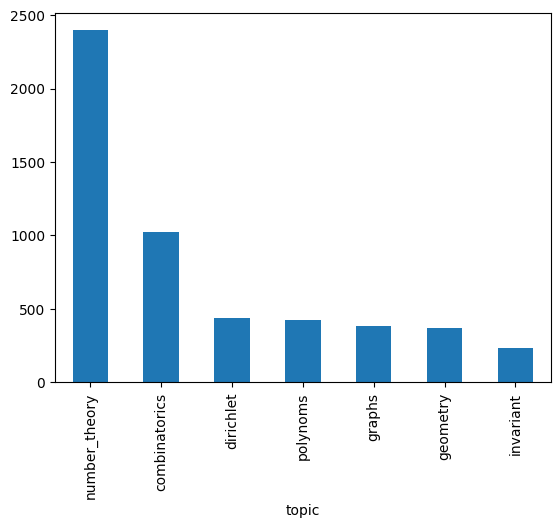

In [ ]:
data['topic'].value_counts().plot(kind='bar')

Видим что есть сильный дисбаланс классов.

Это можно решить на уровне даталоадера, т. е. чаще показывать примеры с меньшей частотностью.

Или на уровне лосса, считать лосс с учетом веса каждого класса. - Используем этот подход.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

def compute_weights_from_labels(labels, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=labels)
    return torch.tensor(weights, dtype=torch.float32)

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [ ]:
model_name = "cointegrated/rubert-tiny2"
rubert_tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset_ru = TextClassificationDataset(X_train.tolist(), y_train.tolist(), rubert_tokenizer)
train_data_loader_ru = DataLoader(train_dataset_ru, batch_size=128, shuffle=True)

test_dataset_ru = TextClassificationDataset(X_test.tolist(), y_test.tolist(), rubert_tokenizer, label2id=train_dataset_ru.label2id)
test_data_loader_ru = DataLoader(test_dataset_ru, batch_size=128, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

#### Считаем веса классов:

In [ ]:
num_classes = len(set(train_dataset_ru.labels))
weights_tensor = compute_weights_from_labels(train_dataset_ru.labels, num_classes)

## Эксперименты:

### Готовим и обучаем **rubert** модель, используем **простую** классификационную голову и **замороженный** backbone:

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=False)
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model,
    train_data_loader_ru,
    test_data_loader_ru,
    num_epochs=50,
    freeze_backbone=True,
    log_dir="runs/rubert_tiny_finetuned_with_freezed_backbone_1",
    checkpoint_dir="checkpoints/rubert_tiny_finetuned_with_freezed_backbone_1",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.2256 — F1_macro: 0.2185 — F1_weighted: 0.2032
[Step 32] Val Acc: 0.3156 — F1_macro: 0.2796 — F1_weighted: 0.3068
[Epoch 1/50] Loss: 1.8894 — Train Acc: 0.3468 — Val Acc: 0.3213 — F1_macro: 0.2816 — F1_weighted: 0.3126
[Step 49] Val Acc: 0.3460 — F1_macro: 0.2996 — F1_weighted: 0.3355
[Step 65] Val Acc: 0.3592 — F1_macro: 0.3167 — F1_weighted: 0.3549
[Epoch 2/50] Loss: 1.7762 — Train Acc: 0.3959 — Val Acc: 0.3621 — F1_macro: 0.3181 — F1_weighted: 0.3591
[Step 82] Val Acc: 0.3659 — F1_macro: 0.3303 — F1_weighted: 0.3662
[Step 98] Val Acc: 0.3943 — F1_macro: 0.3540 — F1_weighted: 0.4011
[Epoch 3/50] Loss: 1.6885 — Train Acc: 0.4154 — Val Acc: 0.3972 — F1_macro: 0.3556 — F1_weighted: 0.4041
[Step 115] Val Acc: 0.4057 — F1_macro: 0.3697 — F1_weighted: 0.4158
[Step 131] Val Acc: 0.4057 — F1_macro: 0.3696 — F1_weighted: 0.4170
[Epoch 4/50] Loss: 1.6257 — Train Acc: 0.4289 — Val Acc: 0.4085 — F1_macro: 0.3720 — F1_weighted: 0.4197
[Step 148] Val Acc: 0.4123 — F1_macro: 0.3

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir runs/rubert_tiny_finetuned_with_freezed_backbone_1

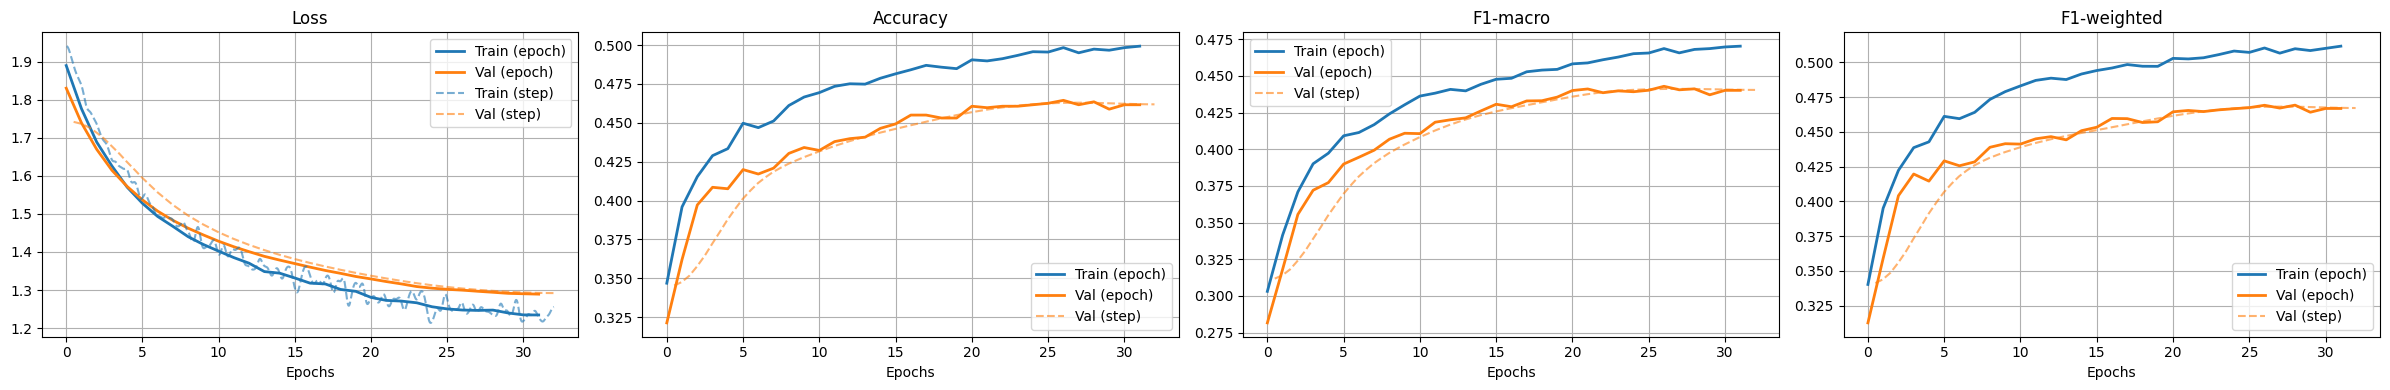

In [ ]:
plot_training_logs("runs/rubert_tiny_finetuned_with_freezed_backbone_1", len(train_data_loader_ru))

### Готовим и обучаем **rubert** модель, используем **сложную** классификационную голову и **замороженный** backbone:

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=True)
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model,
    train_data_loader_ru,
    test_data_loader_ru,
    num_epochs=50,
    freeze_backbone=True,
    log_dir="runs/rubert_tiny_finetuned_with_freezed_backbone_2",
    checkpoint_dir="checkpoints/rubert_tiny_finetuned_with_freezed_backbone_2",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.2294 — F1_macro: 0.2323 — F1_weighted: 0.1592
[Step 32] Val Acc: 0.3848 — F1_macro: 0.3470 — F1_weighted: 0.3868
[Epoch 1/50] Loss: 1.8164 — Train Acc: 0.4142 — Val Acc: 0.3943 — F1_macro: 0.3529 — F1_weighted: 0.3977
[Step 49] Val Acc: 0.4133 — F1_macro: 0.3903 — F1_weighted: 0.4261
[Step 65] Val Acc: 0.4057 — F1_macro: 0.3772 — F1_weighted: 0.4034
[Epoch 2/50] Loss: 1.5009 — Train Acc: 0.4208 — Val Acc: 0.4028 — F1_macro: 0.3696 — F1_weighted: 0.3994
[Step 82] Val Acc: 0.4313 — F1_macro: 0.4127 — F1_weighted: 0.4361
[Step 98] Val Acc: 0.4237 — F1_macro: 0.4108 — F1_weighted: 0.4295
[Epoch 3/50] Loss: 1.3585 — Train Acc: 0.4431 — Val Acc: 0.4275 — F1_macro: 0.4124 — F1_weighted: 0.4333
[Step 115] Val Acc: 0.4256 — F1_macro: 0.3991 — F1_weighted: 0.4189
[Step 131] Val Acc: 0.4417 — F1_macro: 0.4376 — F1_weighted: 0.4611
[Epoch 4/50] Loss: 1.2978 — Train Acc: 0.4628 — Val Acc: 0.4427 — F1_macro: 0.4406 — F1_weighted: 0.4618
[Step 148] Val Acc: 0.4408 — F1_macro: 0.4

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir runs/rubert_tiny_finetuned_with_freezed_backbone_2

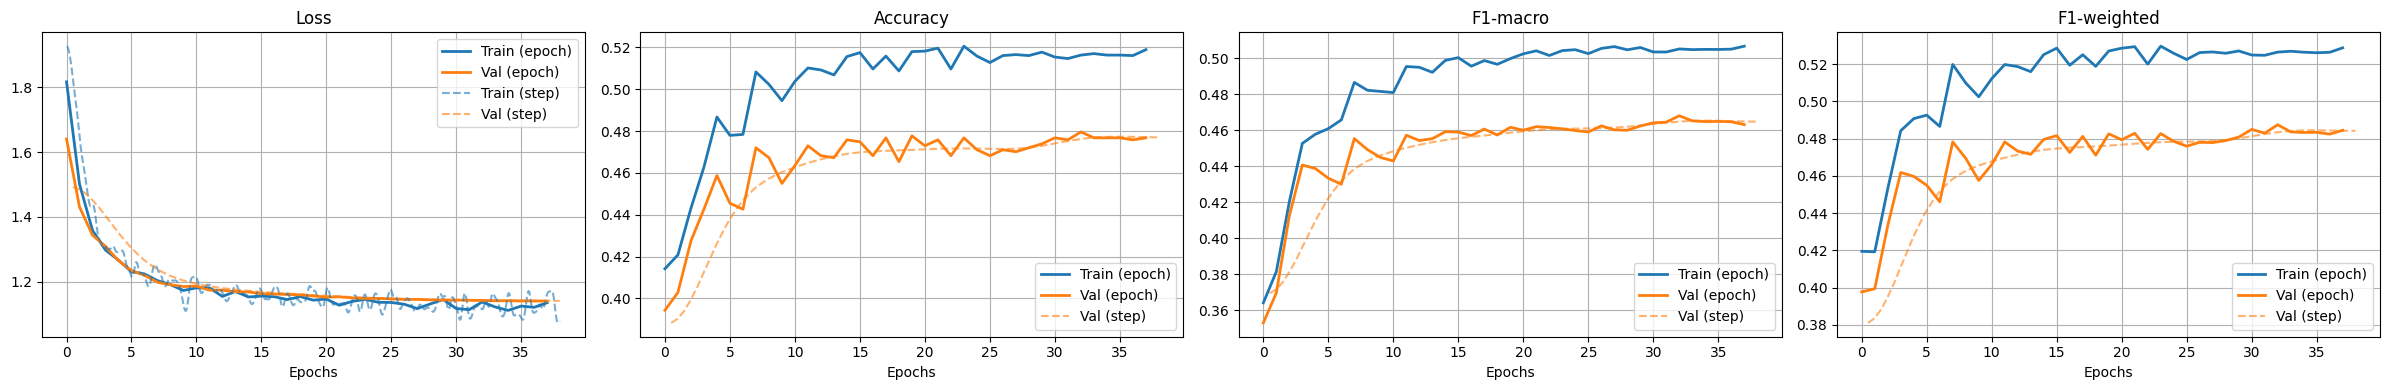

In [ ]:
plot_training_logs("runs/rubert_tiny_finetuned_with_freezed_backbone_2", len(train_data_loader_ru))

# Результат:  

Простая классификационная голова:  
  • **Epoch**: 27  
  • **Accuracy**: 0.4645  
  • **F1_macro**: 0.4429  
  • **F1_weighted**: 0.4691  
  • **Loss**: 1.2998  

Сложная классификационная голова:  
  • **Epoch**: 33  
  • **Accuracy**: 0.4796  
  • **F1_macro**: 0.4680  
  • **F1_weighted**: 0.4874  
  • **Loss**: 1.1425  

Видим что в условиях замороженного backbone значительное влияние оказывает классификационная голова.  
Модель обучается стабильно, но метрики качества невысокие, что связано с упрощенностью используемой модели.

### Готовим и обучаем **rubert** модель, используем **простую** классификационную голову и **размороженный** backbone:

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=False)
rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model,
    train_data_loader_ru,
    test_data_loader_ru,
    num_epochs=50,
    freeze_backbone=False,
    log_dir="runs/rubert_tiny_full_finetuned_1",
    checkpoint_dir="checkpoints/rubert_tiny_full_finetuned_1",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.1981 — F1_macro: 0.1948 — F1_weighted: 0.1585
[Step 32] Val Acc: 0.3081 — F1_macro: 0.2826 — F1_weighted: 0.3022
[Epoch 1/50] Loss: 1.8837 — Train Acc: 0.3400 — Val Acc: 0.3109 — F1_macro: 0.2834 — F1_weighted: 0.3055
[Step 49] Val Acc: 0.3431 — F1_macro: 0.3171 — F1_weighted: 0.3497
[Step 65] Val Acc: 0.3555 — F1_macro: 0.3356 — F1_weighted: 0.3600
[Epoch 2/50] Loss: 1.7487 — Train Acc: 0.3784 — Val Acc: 0.3564 — F1_macro: 0.3361 — F1_weighted: 0.3604
[Step 82] Val Acc: 0.3877 — F1_macro: 0.3545 — F1_weighted: 0.3948
[Step 98] Val Acc: 0.3877 — F1_macro: 0.3668 — F1_weighted: 0.3943
[Epoch 3/50] Loss: 1.6238 — Train Acc: 0.3962 — Val Acc: 0.3858 — F1_macro: 0.3665 — F1_weighted: 0.3937
[Step 115] Val Acc: 0.3943 — F1_macro: 0.3753 — F1_weighted: 0.4001
[Step 131] Val Acc: 0.3943 — F1_macro: 0.3807 — F1_weighted: 0.4024
[Epoch 4/50] Loss: 1.5228 — Train Acc: 0.4033 — Val Acc: 0.3962 — F1_macro: 0.3815 — F1_weighted: 0.4043
[Step 148] Val Acc: 0.4047 — F1_macro: 0.3

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs/rubert_tiny_full_finetuned_1

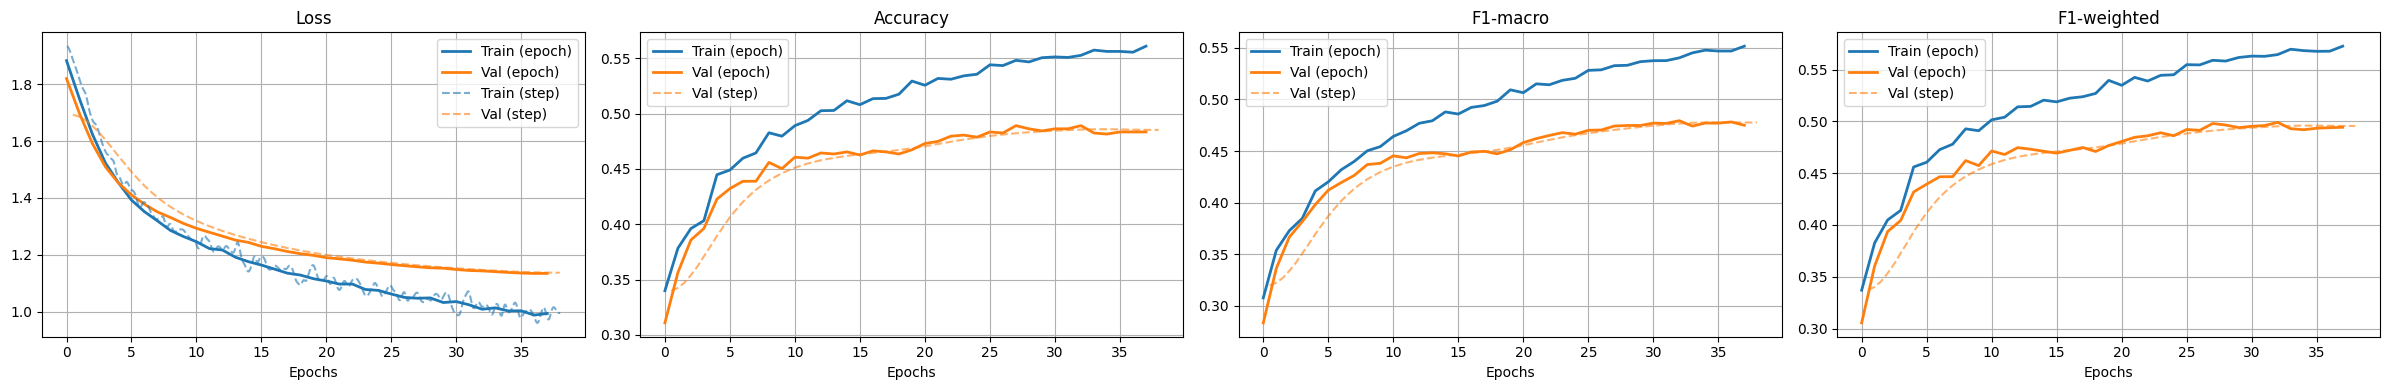

In [ ]:
plot_training_logs("runs/rubert_tiny_full_finetuned_1", len(train_data_loader_ru))

### Готовим и обучаем **rubert** модель, используем **сложную** классификационную голову и **размороженный** backbone:

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=True)
rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model,
    train_data_loader_ru,
    test_data_loader_ru,
    num_epochs=50,
    freeze_backbone=False,
    log_dir="runs/rubert_tiny_full_finetuned_2",
    checkpoint_dir="checkpoints/rubert_tiny_full_finetuned_2",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.2171 — F1_macro: 0.1966 — F1_weighted: 0.1535
[Step 32] Val Acc: 0.3280 — F1_macro: 0.3425 — F1_weighted: 0.3277
[Epoch 1/50] Loss: 1.7995 — Train Acc: 0.3573 — Val Acc: 0.3412 — F1_macro: 0.3497 — F1_weighted: 0.3462
[Step 49] Val Acc: 0.3763 — F1_macro: 0.3354 — F1_weighted: 0.3709
[Step 65] Val Acc: 0.4085 — F1_macro: 0.3965 — F1_weighted: 0.4188
[Epoch 2/50] Loss: 1.4666 — Train Acc: 0.4165 — Val Acc: 0.4095 — F1_macro: 0.3970 — F1_weighted: 0.4190
[Step 82] Val Acc: 0.4284 — F1_macro: 0.4119 — F1_weighted: 0.4334
[Step 98] Val Acc: 0.4379 — F1_macro: 0.4198 — F1_weighted: 0.4488
[Epoch 3/50] Loss: 1.3311 — Train Acc: 0.4694 — Val Acc: 0.4445 — F1_macro: 0.4204 — F1_weighted: 0.4542
[Step 115] Val Acc: 0.4379 — F1_macro: 0.4316 — F1_weighted: 0.4513
[Step 131] Val Acc: 0.4664 — F1_macro: 0.4453 — F1_weighted: 0.4745
[Epoch 4/50] Loss: 1.2725 — Train Acc: 0.4910 — Val Acc: 0.4559 — F1_macro: 0.4393 — F1_weighted: 0.4623
[Step 148] Val Acc: 0.4701 — F1_macro: 0.4

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs/rubert_tiny_full_finetuned_2

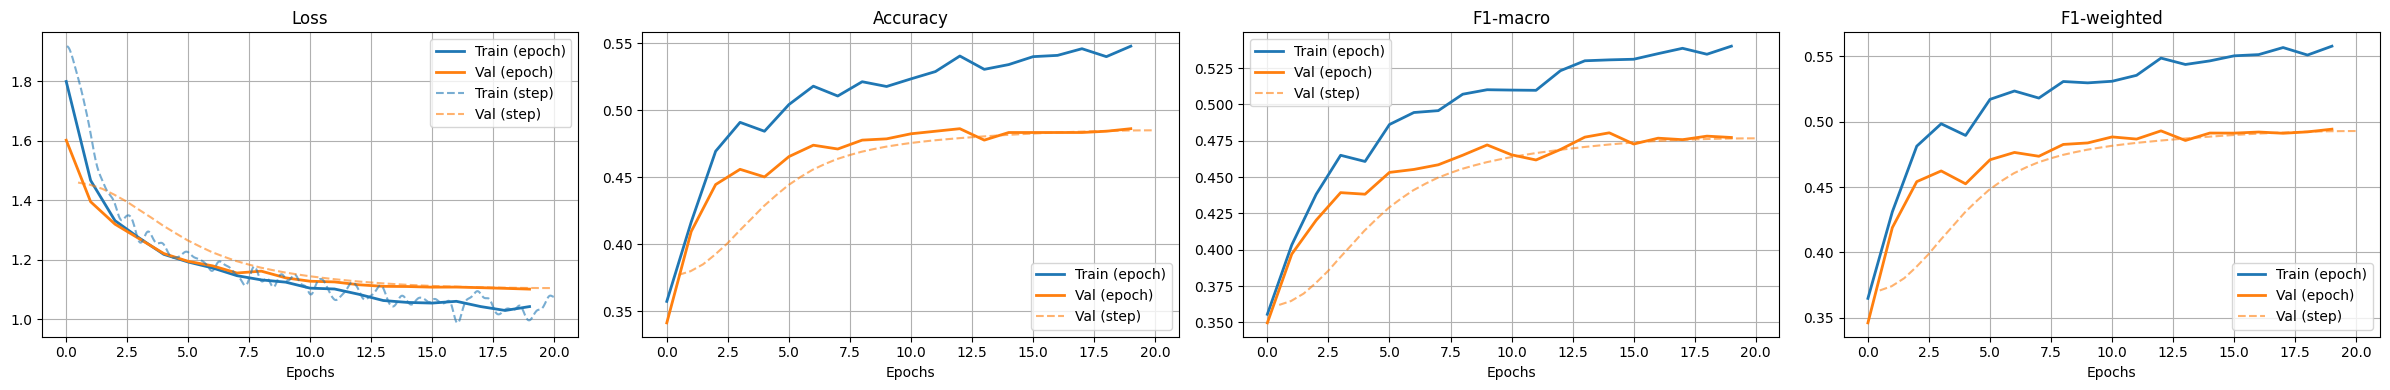

In [ ]:
plot_training_logs("runs/rubert_tiny_full_finetuned_2", len(train_data_loader_ru))

# Результат:  

Простая классификационная голова:  
  • **Epoch**: 33  
  • **Accuracy**: 0.4891  
  • **F1_macro**: 0.4794  
  • **F1_weighted**: 0.4990  
  • **Loss**: 1.1431  

Сложная классификационная голова:  
  • **Epoch**: 15  
  • **Accuracy**: 0.4834  
  • **F1_macro**: 0.4804  
  • **F1_weighted**: 0.4913  
  • **Loss**: 1.1095

Видим что в условиях размороженного backbone классификационная голова оказывает уже не такое выраженное влияние.  
Модель обучается стабильно, но метрики качества также невысокие, что связано с упрощенностью используемой модели.  

Эксперименты показали что разморозка backbone дает ощутимый прирост качества.

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [ ]:
model_name = "tbs17/MathBERT"
mathbert_tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset_math = TextClassificationDataset(X_train.tolist(), y_train.tolist(), mathbert_tokenizer)
train_data_loader_math = DataLoader(train_dataset_math, batch_size=128, shuffle=True)

test_dataset_math = TextClassificationDataset(X_test.tolist(), y_test.tolist(), mathbert_tokenizer, label2id=train_dataset_math.label2id)
test_data_loader_math = DataLoader(test_dataset_math, batch_size=128, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### Готовим и обучаем **mathbert** модель, используем **простую** классификационную голову и **замороженный** backbone:

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=False, pooling='mean')
mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_transformer_model,
    train_data_loader_math,
    test_data_loader_math,
    num_epochs=50,
    freeze_backbone=True,
    log_dir="runs/mathbert_finetuned_with_freezed_backbone_1",
    checkpoint_dir="checkpoints/mathbert_finetuned_with_freezed_backbone_1",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[Step 16] Val Acc: 0.3839 — F1_macro: 0.3712 — F1_weighted: 0.3924
[Step 32] Val Acc: 0.4720 — F1_macro: 0.4232 — F1_weighted: 0.4678
[Epoch 1/50] Loss: 1.6424 — Train Acc: 0.5114 — Val Acc: 0.4739 — F1_macro: 0.4262 — F1_weighted: 0.4699
[Step 49] Val Acc: 0.4607 — F1_macro: 0.4320 — F1_weighted: 0.4766
[Step 65] Val Acc: 0.4730 — F1_macro: 0.4393 — F1_weighted: 0.4820
[Epoch 2/50] Loss: 1.2875 — Train Acc: 0.5239 — Val Acc: 0.4739 — F1_macro: 0.4404 — F1_weighted: 0.4824
[Step 82] Val Acc: 0.4578 — F1_macro: 0.4300 — F1_weighted: 0.4705
[Step 98] Val Acc: 0.4777 — F1_macro: 0.4423 — F1_weighted: 0.4918
[Epoch 3/50] Loss: 1.1747 — Train Acc: 0.5472 — Val Acc: 0.4768 — F1_macro: 0.4405 — F1_weighted: 0.4913
[Step 115] Val Acc: 0.4664 — F1_macro: 0.4344 — F1_weighted: 0.4793
[Step 131] Val Acc: 0.4569 — F1_macro: 0.4400 — F1_weighted: 0.4787
[Epoch 4/50] Loss: 1.1184 — Train Acc: 0.5346 — Val Acc: 0.4607 — F1_macro: 0.4410 — F1_weighted: 0.4805
[Step 148] Val Acc: 0.4635 — F1_macro: 0.4

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs/mathbert_finetuned_with_freezed_backbone_1

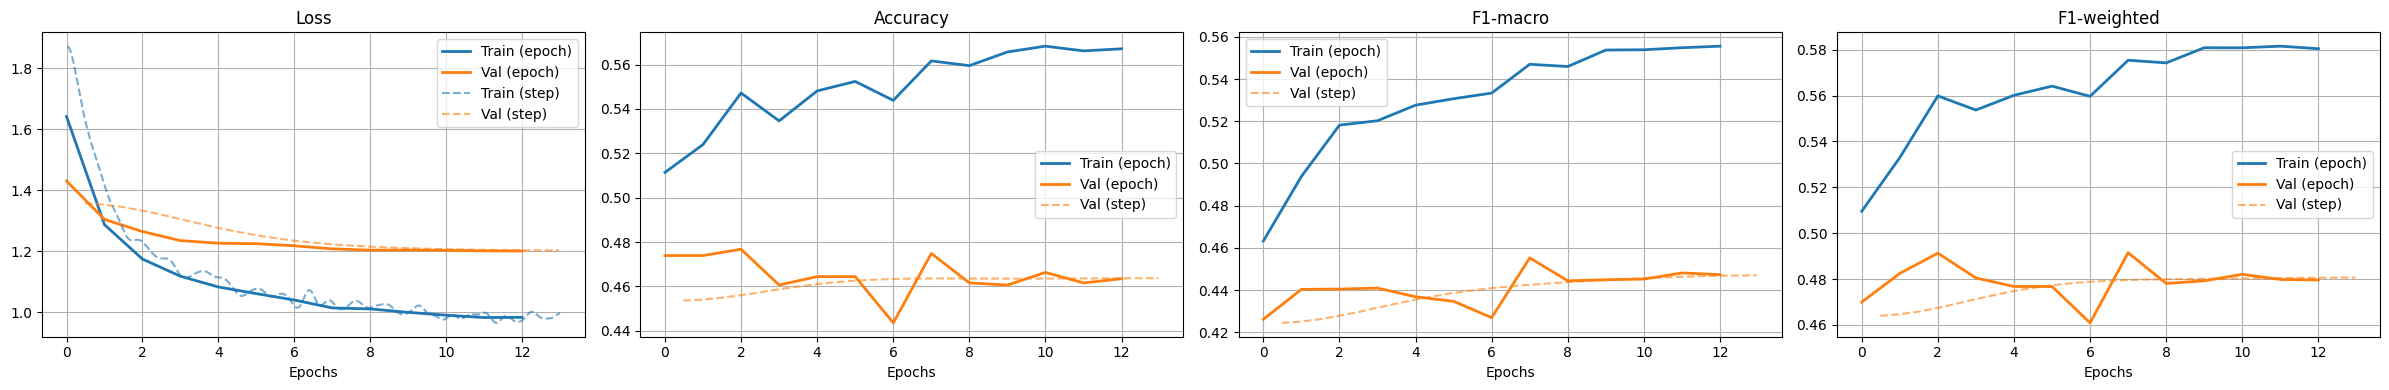

In [ ]:
plot_training_logs("runs/mathbert_finetuned_with_freezed_backbone_1", len(train_data_loader_math))

### Готовим и обучаем **mathbert** модель, используем **сложную** классификационную голову и **замороженный** backbone:

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=True, pooling='mean')
mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model,
    train_data_loader_math,
    test_data_loader_math,
    num_epochs=50,
    freeze_backbone=True,
    log_dir="runs/mathbert_finetuned_with_freezed_backbone_2",
    checkpoint_dir="checkpoints/mathbert_finetuned_with_freezed_backbone_2",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.4218 — F1_macro: 0.3937 — F1_weighted: 0.4351
[Step 32] Val Acc: 0.4521 — F1_macro: 0.4055 — F1_weighted: 0.4540
[Epoch 1/50] Loss: 1.4889 — Train Acc: 0.4962 — Val Acc: 0.4445 — F1_macro: 0.3993 — F1_weighted: 0.4479
[Step 49] Val Acc: 0.3877 — F1_macro: 0.4083 — F1_weighted: 0.3952
[Step 65] Val Acc: 0.4066 — F1_macro: 0.4201 — F1_weighted: 0.4159
[Epoch 2/50] Loss: 1.1606 — Train Acc: 0.4692 — Val Acc: 0.4009 — F1_macro: 0.4147 — F1_weighted: 0.4060
[Step 82] Val Acc: 0.4313 — F1_macro: 0.4179 — F1_weighted: 0.4456
[Step 98] Val Acc: 0.4692 — F1_macro: 0.4625 — F1_weighted: 0.4903
[Epoch 3/50] Loss: 1.0829 — Train Acc: 0.5669 — Val Acc: 0.4673 — F1_macro: 0.4552 — F1_weighted: 0.4867
[Step 115] Val Acc: 0.4749 — F1_macro: 0.4675 — F1_weighted: 0.4947
[Step 131] Val Acc: 0.4464 — F1_macro: 0.4384 — F1_weighted: 0.4541
[Epoch 4/50] Loss: 1.0552 — Train Acc: 0.5351 — Val Acc: 0.4502 — F1_macro: 0.4373 — F1_weighted: 0.4570
[Step 148] Val Acc: 0.4502 — F1_macro: 0.4

In [ ]:
%load_ext tensorboard
%tensorboard --logdir rubert_tiny_finetuned_with_freezed_backbone_2

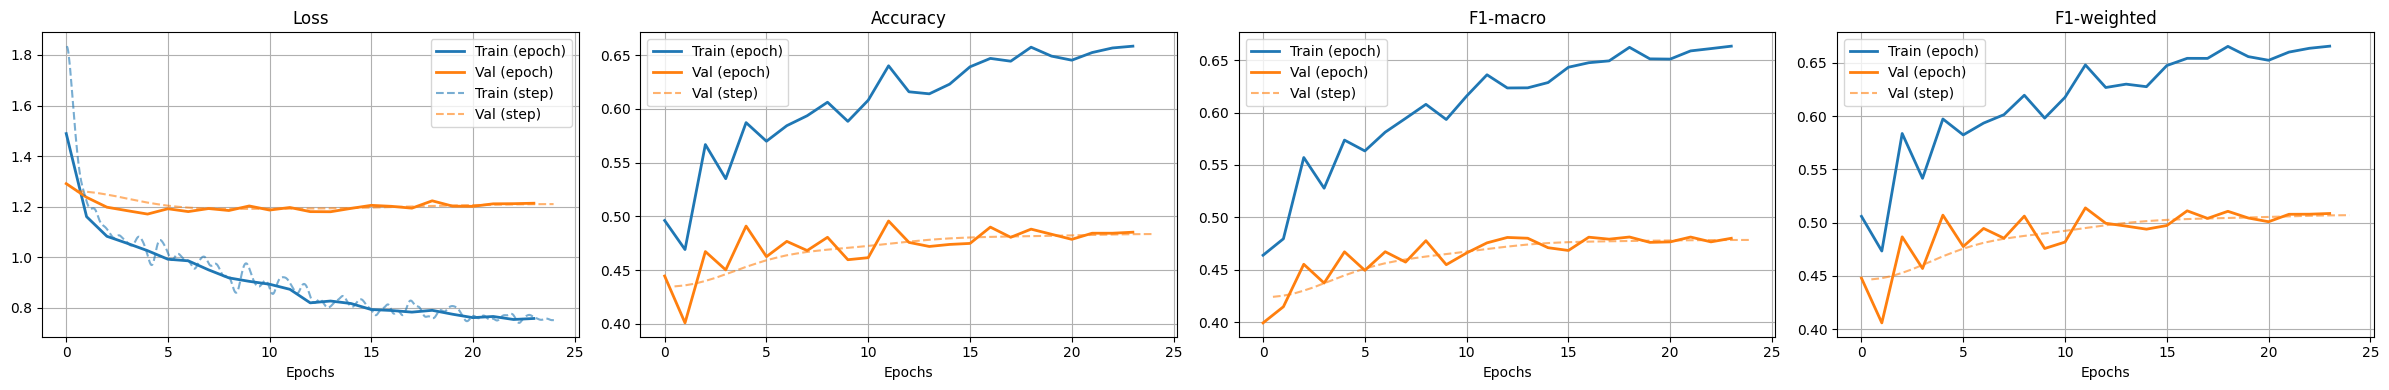

In [ ]:
plot_training_logs("runs/mathbert_finetuned_with_freezed_backbone_2", len(train_data_loader_math))

# Результат:  

Простая классификационная голова:  
  • **Epoch**: 8  
  • **Accuracy**: 0.4749  
  • **F1_macro**: 0.4553  
  • **F1_weighted**: 0.4915  
  • **Loss**: 1.2082  

Сложная классификационная голова:  
  • **Epoch**: 19  
  • **Accuracy**: 0.4882  
  • **F1_macro**: 0.4813  
  • **F1_weighted**: 0.5106  
  • **Loss**: 1.2232  

Модель обучается не стабильно, метрики качества невысокие.  
Модель показала качество ощутимо лучше чем rubert-tiny в случае простой и сложной классификационной головы.  

### Готовим и обучаем **mathbert** модель, используем **простую** классификационную голову и **размороженный** backbone:

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=False, pooling='mean')
mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model,
    train_data_loader_math,
    test_data_loader_math,
    num_epochs=50,
    freeze_backbone=False,
    log_dir="runs/mathbert_full_finetuned_1",
    checkpoint_dir="checkpoints/mathbert_full_finetuned_1",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.4000 — F1_macro: 0.3801 — F1_weighted: 0.4075
[Step 32] Val Acc: 0.4521 — F1_macro: 0.4068 — F1_weighted: 0.4616
[Epoch 1/50] Loss: 1.6080 — Train Acc: 0.4976 — Val Acc: 0.4550 — F1_macro: 0.4168 — F1_weighted: 0.4665
[Step 49] Val Acc: 0.4607 — F1_macro: 0.4157 — F1_weighted: 0.4611
[Step 65] Val Acc: 0.4408 — F1_macro: 0.4321 — F1_weighted: 0.4586
[Epoch 2/50] Loss: 1.2176 — Train Acc: 0.4945 — Val Acc: 0.4351 — F1_macro: 0.4290 — F1_weighted: 0.4532
[Step 82] Val Acc: 0.4616 — F1_macro: 0.4272 — F1_weighted: 0.4688
[Step 98] Val Acc: 0.4664 — F1_macro: 0.4377 — F1_weighted: 0.4778
[Epoch 3/50] Loss: 1.1061 — Train Acc: 0.5469 — Val Acc: 0.4692 — F1_macro: 0.4381 — F1_weighted: 0.4808
[Step 115] Val Acc: 0.4540 — F1_macro: 0.4330 — F1_weighted: 0.4691
[Step 131] Val Acc: 0.4768 — F1_macro: 0.4492 — F1_weighted: 0.4875
[Epoch 4/50] Loss: 1.0409 — Train Acc: 0.5552 — Val Acc: 0.4711 — F1_macro: 0.4448 — F1_weighted: 0.4816
[Step 148] Val Acc: 0.4645 — F1_macro: 0.4

In [ ]:
%load_ext tensorboard
%tensorboard --logdir mathbert_full_finetuned_1

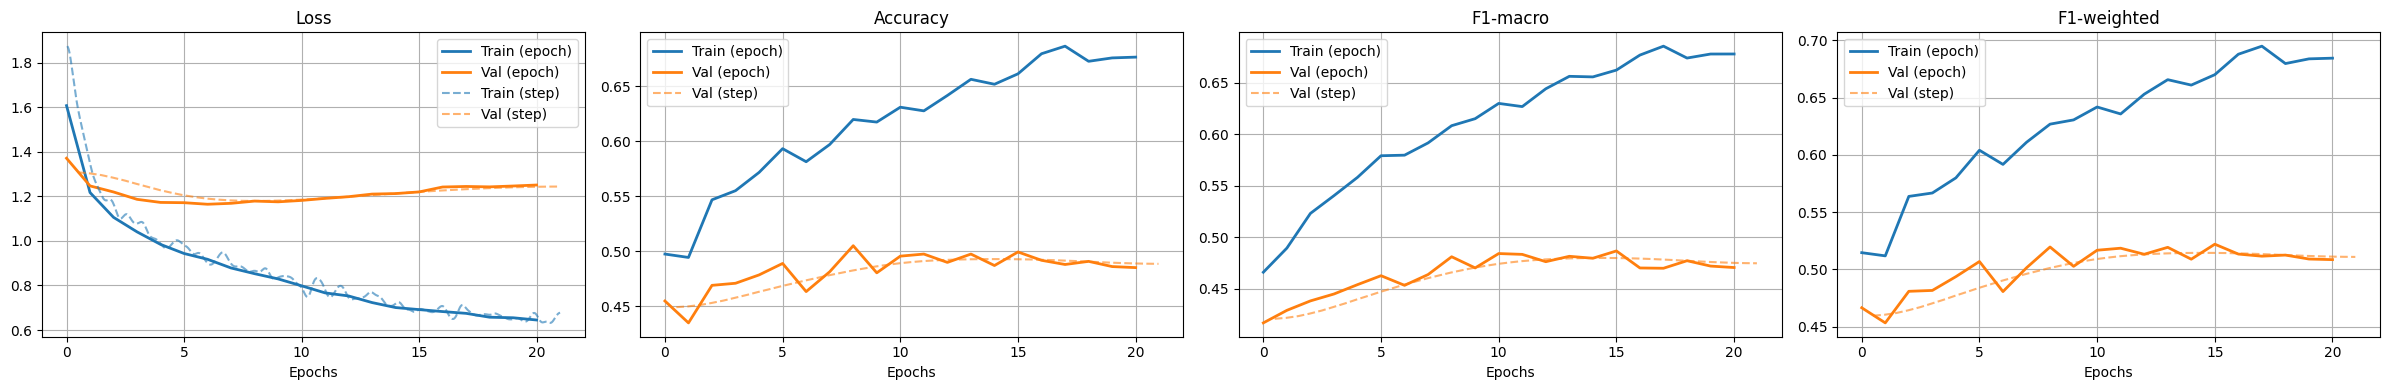

In [ ]:
plot_training_logs("runs/mathbert_full_finetuned_1", len(train_data_loader_math))

### Готовим и обучаем **mathbert** модель, используем **сложную** классификационную голову и **размороженный** backbone:

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(model_name, num_classes=data.topic.nunique(), use_complex_head=True, pooling='mean')
mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model,
    train_data_loader_math,
    test_data_loader_math,
    num_epochs=50,
    freeze_backbone=False,
    log_dir="runs/mathbert_full_finetuned_2",
    checkpoint_dir="checkpoints/mathbert_full_finetuned_2",
    early_stopping_patience=5,
    class_weights=weights_tensor
    )

0.000 of 50 epochs:   0%|          | 0/1650 [00:00<?, ?it/s]

[Step 16] Val Acc: 0.4474 — F1_macro: 0.3901 — F1_weighted: 0.4462
[Step 32] Val Acc: 0.4379 — F1_macro: 0.4193 — F1_weighted: 0.4461
[Epoch 1/50] Loss: 1.4786 — Train Acc: 0.4808 — Val Acc: 0.4370 — F1_macro: 0.4292 — F1_weighted: 0.4460
[Step 49] Val Acc: 0.4493 — F1_macro: 0.4349 — F1_weighted: 0.4612
[Step 65] Val Acc: 0.4749 — F1_macro: 0.4443 — F1_weighted: 0.4886
[Epoch 2/50] Loss: 1.1322 — Train Acc: 0.5652 — Val Acc: 0.4777 — F1_macro: 0.4464 — F1_weighted: 0.4930
[Step 82] Val Acc: 0.4806 — F1_macro: 0.4616 — F1_weighted: 0.5032
[Step 98] Val Acc: 0.4796 — F1_macro: 0.4509 — F1_weighted: 0.4924
[Epoch 3/50] Loss: 1.0440 — Train Acc: 0.5970 — Val Acc: 0.4891 — F1_macro: 0.4532 — F1_weighted: 0.4994
[Step 115] Val Acc: 0.4597 — F1_macro: 0.4602 — F1_weighted: 0.4815
[Step 131] Val Acc: 0.4597 — F1_macro: 0.4567 — F1_weighted: 0.4803
[Epoch 4/50] Loss: 0.9831 — Train Acc: 0.5785 — Val Acc: 0.4711 — F1_macro: 0.4651 — F1_weighted: 0.4896
[Step 148] Val Acc: 0.4464 — F1_macro: 0.4

In [ ]:
%load_ext tensorboard
%tensorboard --logdir mathbert_full_finetuned_2

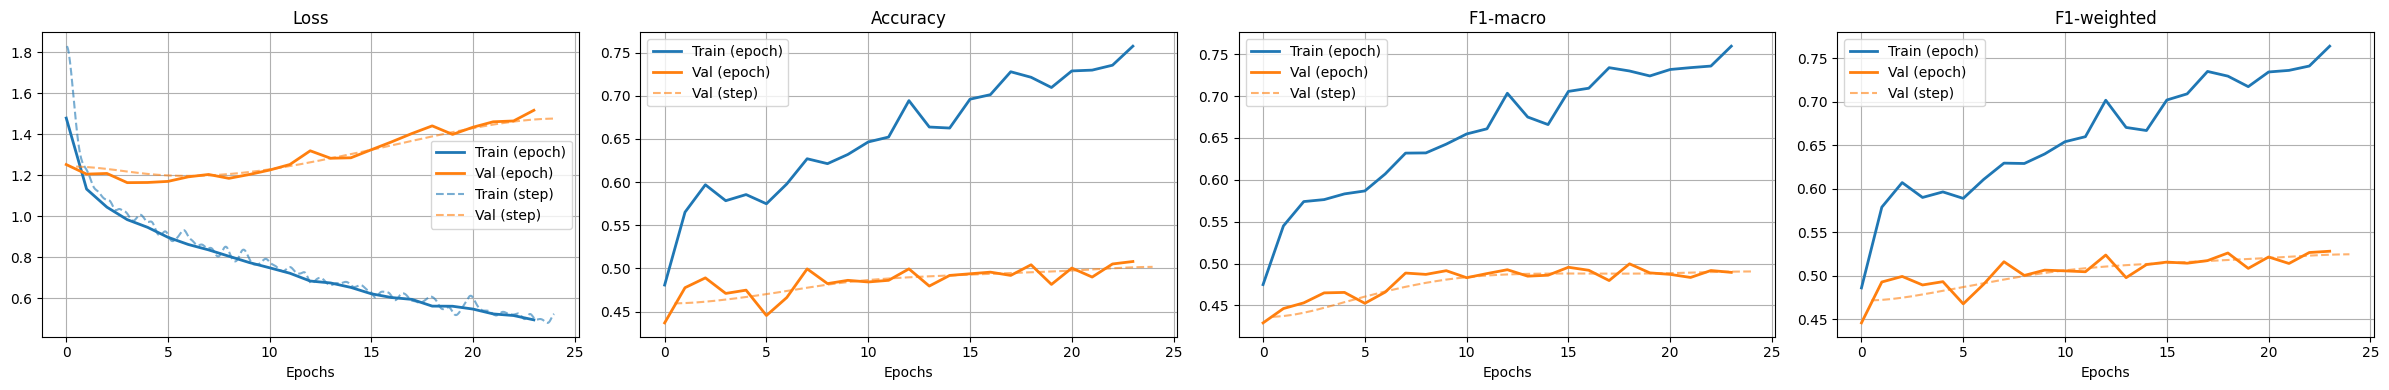

In [ ]:
plot_training_logs("runs/mathbert_full_finetuned_2", len(train_data_loader_math))

# Результат:  

Простая классификационная голова:  
  • **Epoch**: 16  
  • **Accuracy**: 0.4995  
  • **F1_macro**: 0.4867  
  • **F1_weighted**: 0.5220  
  • **Loss**: 1.2203  

Сложная классификационная голова:  
  • **Epoch**: 19  
  • **Accuracy**: 0.5043  
  • **F1_macro**: 0.4997  
  • **F1_weighted**: 0.5264  
  • **Loss**: 1.4405

Видим что в условиях размороженного backbone классификационная голова оказывает уже не такое выраженное влияние.  
Модель обучается не стабильно, метрики качества невысокие.  
Модель mathbert с размороженным backbone и сложной классификационной головой показала лучшее качество.  
Модель mathbert показала качество ощутимо лучше чем rubert-tiny в случае простой и сложной классификационной головы.  

Эксперименты показали что разморозка backbone дает ощутимый прирост качества.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
def visualize_attention_on_text(
    model_or_name: Union[str, torch.nn.Module],
    texts: List[str],
    head_ids: List[int] = [0, 1, 2]
):
    if isinstance(model_or_name, str):
        tokenizer = AutoTokenizer.from_pretrained(model_or_name)
        model = AutoModel.from_pretrained(model_or_name, output_attentions=True)
    else:
        model = model_or_name
        if hasattr(model, 'config'):
            model.config.output_attentions = True
            model_name = getattr(model.config, "name_or_path", "custom_model")
        else:
            raise ValueError("Model must have a config to enable attention outputs.")
        tokenizer = AutoTokenizer.from_pretrained(model_name)

    model.eval()
    device = next(model.parameters()).device  # ➕ Automatically detect model's device

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}  # ➕ Move inputs to model's device

        with torch.no_grad():
            outputs = model(**inputs)

        if not hasattr(outputs, "attentions") or outputs.attentions is None:
            raise ValueError("Model did not return attention weights. Make sure output_attentions=True")

        attentions = outputs.attentions
        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())
        seq_len = len(tokens)
        first_layer_attention = attentions[0][0]  # (num_heads, seq_len, seq_len)

        print(f"\nText: {text}")
        for head_id in head_ids:
            attn = first_layer_attention[head_id, :seq_len, :seq_len].cpu().numpy()

            plt.figure(figsize=(8, 6))
            plt.imshow(attn, cmap="viridis")
            plt.colorbar()
            plt.xticks(ticks=range(seq_len), labels=tokens, rotation=90)
            plt.yticks(ticks=range(seq_len), labels=tokens)
            plt.title(f"Head {head_id} — Layer 0")
            plt.tight_layout()
            plt.show()


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [ ]:
texts = X_test.sample(3)

### Rubert


Text: (a) Are there four such different natural numbers 


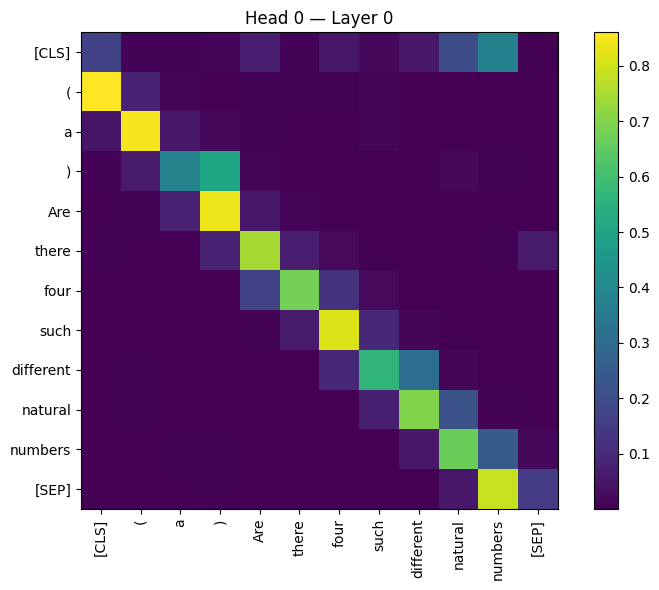


Text: There are 13 grey, 15 brown and 17 raspberry chame


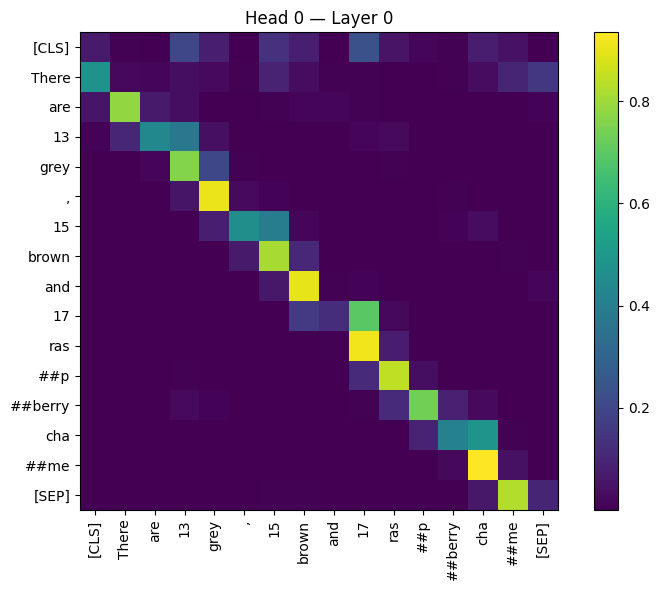


Text: There are 13 girs, each weighing an entire number 


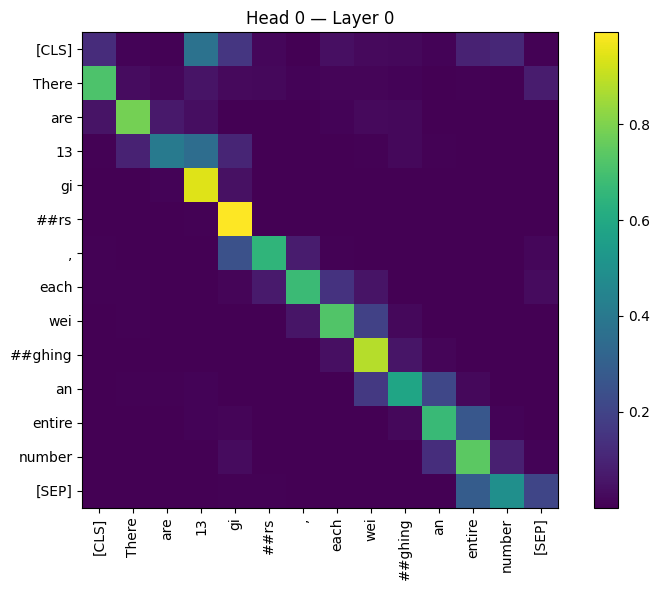

In [ ]:
visualize_attention_on_text("cointegrated/rubert-tiny2", head_ids=[0], texts=[t[:50] for t in texts])

Слой 0 как правило моделирует локальные синтаксические связи.  
Так же видим фокус в пределах окна 1–2 токена.  

### Mathbert

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Text: (a) Are there four such different natural numbers 


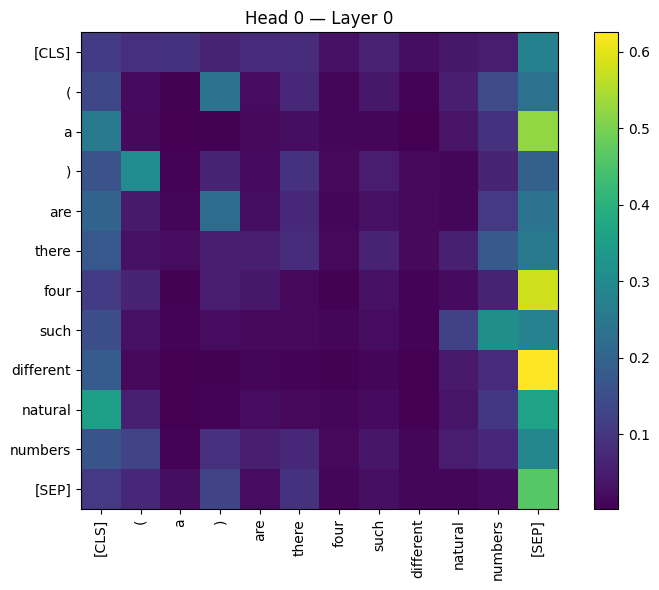


Text: There are 13 grey, 15 brown and 17 raspberry chame


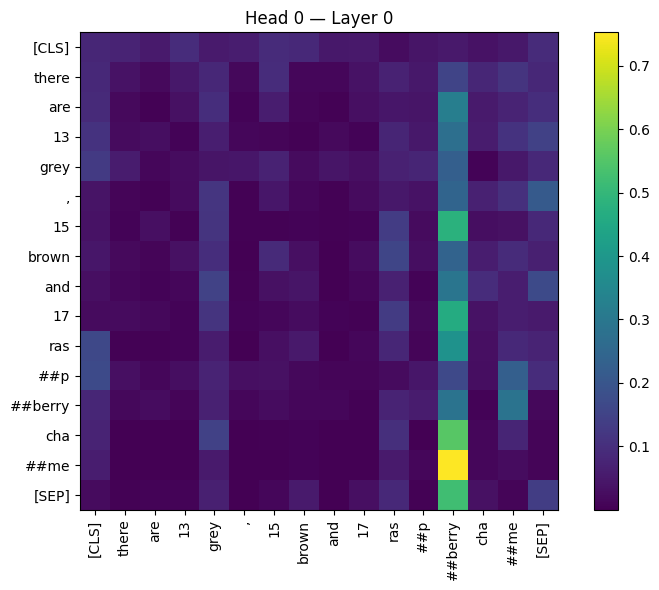


Text: There are 13 girs, each weighing an entire number 


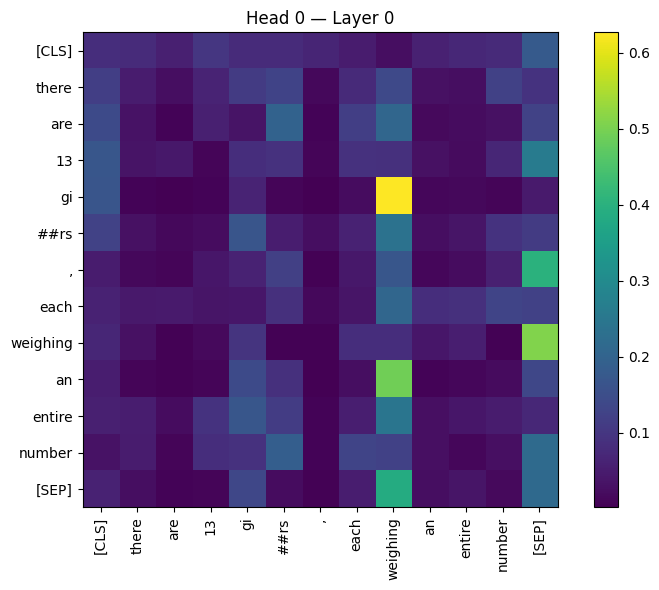

In [ ]:
visualize_attention_on_text("tbs17/MathBERT", head_ids=[0], texts=[t[:50] for t in texts])

Здесь же видим уже на первом слое усилинное внимание на несколько токенов.  
Так же отсутствует диагональное поведение как у rubert.  
Это значит что модель должна хорошо оперировать математическими текстами.

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

### Rubert


Text: (a) Are there four such different natural numbers 


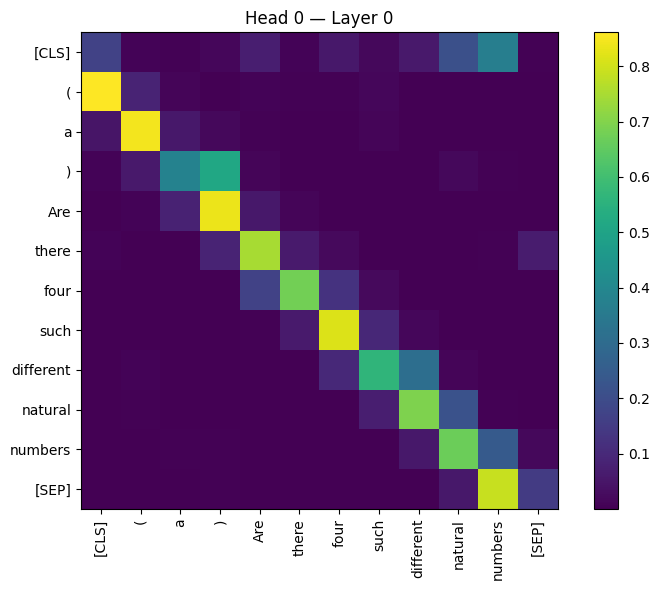


Text: There are 13 grey, 15 brown and 17 raspberry chame


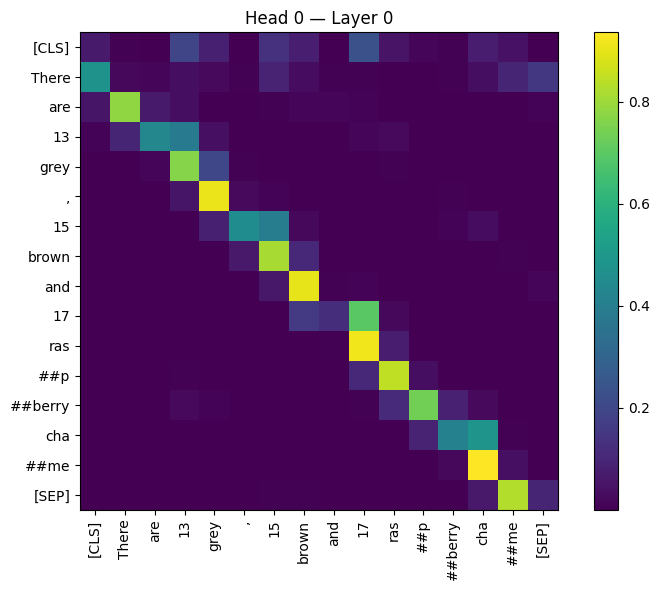


Text: There are 13 girs, each weighing an entire number 


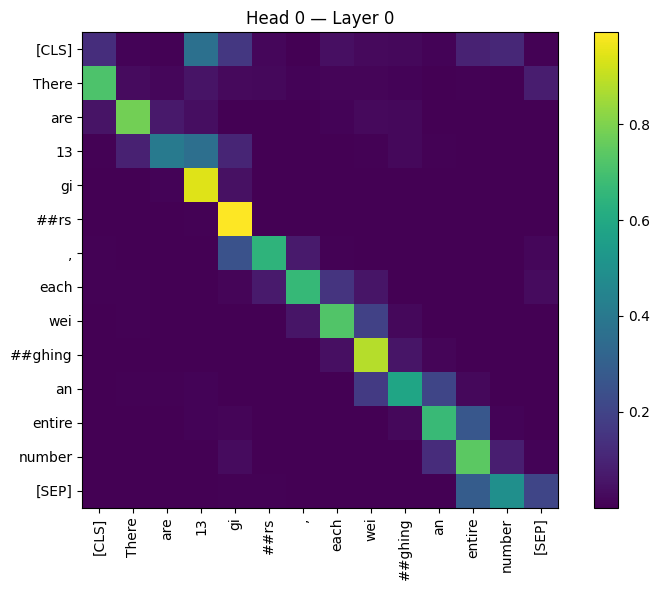

In [ ]:
visualize_attention_on_text(rubert_tiny_full_finetuned.backbone, head_ids=[0], texts=[t[:50] for t in texts])

После дообучения не заметил значительных изменений на первом слое.

### Mathbert

In [ ]:
texts = [
    '(a) Are there four such different natural numbers',
    'There are 13 grey, 15 brown and 17 raspberry chame',
    'There are 13 girs, each weighing an entire number'
]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Text: (a) Are there four such different natural numbers


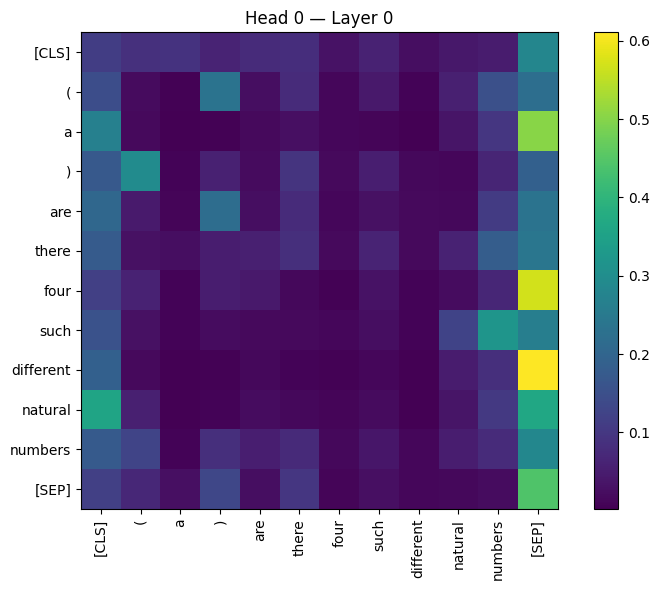


Text: There are 13 grey, 15 brown and 17 raspberry chame


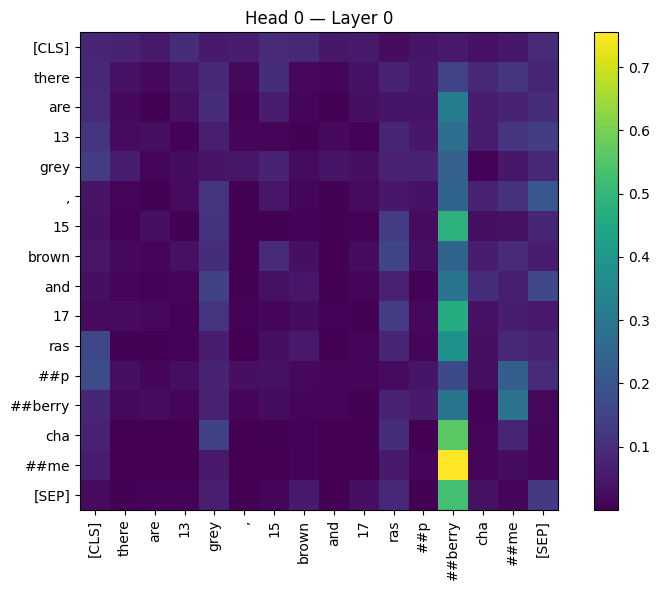


Text: There are 13 girs, each weighing an entire number


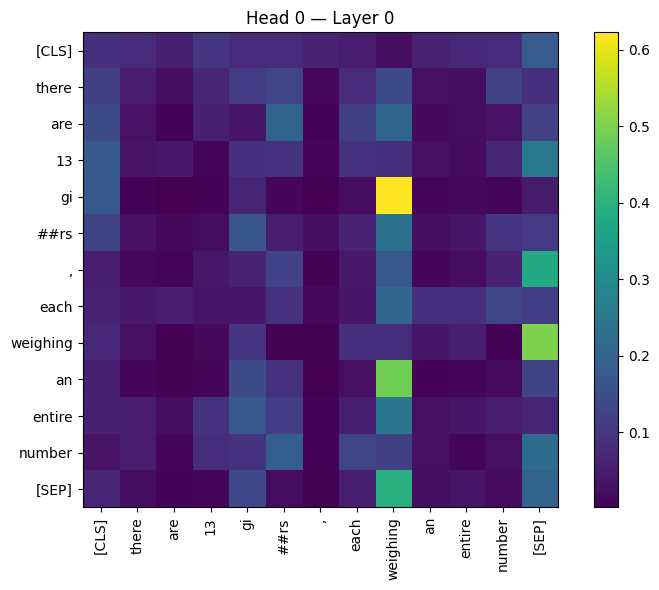

In [ ]:
visualize_attention_on_text(mathbert_full_finetuned.backbone, head_ids=[0], texts=[t[:50] for t in texts])

Так же не вижу значимых изменений на первом слое.

## Итоговый отчет:  

Проведены следующие эксперименты:

Для **rubert**:  

1.   **Замороженный** backbone rubert-tiny + **простая** classification head: F1_macro: **0.4429**
2.   **Замороженный** backbone rubert-tiny + **сложная** classification head: F1_macro: **0.4680**
3.   **Размороженный** backbone rubert-tiny + **простая** classification head: F1_macro: **0.4794**
4.   **Размороженный** backbone rubert-tiny + **сложная** classification head: F1_macro: **0.4804**


Для **mathbert**:

1.   **Замороженный** backbone mathbert + **простая** classification head: F1_macro: **0.4553**
2.   **Замороженный** backbone mathbert + **сложная** classification head: F1_macro: **0.4813**
3.   **Размороженный** backbone mathbert + **простая** classification head: F1_macro: **0.4867**
4.   **Размороженный** backbone mathbert + **сложная** classification head: F1_macro: **0.4997**

Во всех экспериментах усложнения классификационной головы давали прирост качества.  
Также разморозка backbone давала прирост качетсва во всех экспериментах.  
**Лучшее качество** показала модель **Размороженный** backbone mathbert + **сложная** classification head  
**Лучшее итоговое качество** в терминах метрики F1_macro: **0.4997**
